# — SPORT_NEWS IA

## Objectif

Ce notebook explore le dataset MLSUM-FR pour extraire et caractériser les articles sportifs qui servirons de base à l'entraînement et à l'évaluation des modèles de résumé.

## Plan

1. Chargement du dataset MLSUM-FR
2. Exploration des articles disponibles
3. Filtrage sur les articles sportifs
4. Statistiques descriptives (volumes, longueurs)
5. Visualisations
6. Échantillons qualitatifs
7. Sauvegarde du dataset filtré

## Source des données

[MLSUM (HuggingFace)](https://huggingface.co/datasets/reciTAL/mlsum) — Multilingual Summarization Corpus, configuration française basée sur les articles du quotidien *Le Monde*.

In [24]:
# Librairies standard
import os
import warnings
from pathlib import Path


import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

# pour pouvoir importer depuis HuggingFace
from datasets import load_dataset


warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid", palette="deep")

# Chemin de sortie pour le dataset filtré
DATA_DIR = Path("../data")
DATA_DIR.mkdir(exist_ok=True)

print("Imports OK")

Imports OK


## 1. Chargement du dataset MLSUM-FR

Le dataset MLSUM contient des articles de presse dans plusieurs langues, tous sont relier à un résumé de référence ainsi qu'à des métadonnées (topic, titre, date, URL).

ici on prendra uniquement la configuration française. Pour limiter le temps d'exploration initial, nous travaillons d'abord sur le split `train` qui constitue la majorité du dataset.

In [25]:
# Chargement de MLSUM-FR depuis HuggingFace


BASE_URL = "hf://datasets/reciTAL/mlsum@refs/convert/parquet/fr"

dataset = load_dataset(
    "parquet",
    data_files={
        "train":      f"{BASE_URL}/train/*.parquet",
        "validation": f"{BASE_URL}/validation/*.parquet",
        "test":       f"{BASE_URL}/test/*.parquet",
    },
)

print("Splits disponibles :", list(dataset.keys()))
print()
for split_name in dataset.keys():
    print(f"  {split_name:10s} → {len(dataset[split_name]):,} articles")

Splits disponibles : ['train', 'validation', 'test']

  train      → 392,902 articles
  validation → 16,059 articles
  test       → 15,828 articles


In [26]:
# Conversion en DataFrame pandas pour faciliter l'exploration
df_train = dataset["train"].to_pandas()

print(f"Total articles (train) : {len(df_train):,}")
print(f"Nombre de topics uniques : {df_train['topic'].nunique()}")
print()

# Top 30 topics les plus fréquents
top_topics = df_train["topic"].value_counts().head(30)
print("TOP 30 topics :")
print(top_topics.to_string())

Total articles (train) : 392,902
Nombre de topics uniques : 580

TOP 30 topics :
topic
economie             42975
idees                24271
politique            24063
societe              23341
europe               21651
afrique              17632
sport                16049
culture              15121
planete              13636
proche-orient        11891
ameriques            11793
asie-pacifique       10213
international        10203
livres                8265
technologies          6362
cinema                6169
pixels                6065
vous                  5339
m-styles              5129
sciences              4599
les-decodeurs         4386
campus                4118
police-justice        3998
actualite-medias      3711
blog                  3470
televisions-radio     3430
m-actu                3411
football              3096
disparitions          3070
a-la-une              2874


## 2. Exploration des topics

Chaque article MLSUM-FR est associé à un `topic` (rubrique du Monde). Cette colonne est importante pour notre projet : c'est elle qui va nous permettre d'isoler les articles sportifs.

Nous explorons ici la distribution des topics dans le split `train` pour identifier ceux qui sont lié au sport.

In [27]:
# On identifie tous les topics liés au sport via mots-clés
SPORT_KEYWORDS = [
    "sport", "football", "ligue", "tennis", "rugby", "basket",
    "cyclisme", "tour-de-france", "roland-garros", "athletisme",
    "formule-1", "f1", "ski", "handball", "top-14",
    "jeux-olympiques", "coupe-du-monde", "champions", "voile",
    "boxe", "natation", "golf",
]

all_topics = df_train["topic"].dropna().unique()
sport_topics = [
    t for t in all_topics
    if any(kw in str(t).lower() for kw in SPORT_KEYWORDS)
]

print(f"Topics identifiés comme sportifs : {len(sport_topics)}")
print()
for t in sorted(sport_topics):
    count = (df_train["topic"] == t).sum()
    print(f"  {t:30s} → {count:>6,} articles")

Topics identifiés comme sportifs : 36

  athletisme                     →    281 articles
  basket                         →    283 articles
  blog-du-tour-de-france         →     39 articles
  blog-roland-garros             →     18 articles
  championnats-monde-athletisme  →      2 articles
  coupe-du-monde                 →    621 articles
  coupe-du-monde-rugby           →    180 articles
  cyclisme                       →    328 articles
  football                       →  3,096 articles
  formule-1                      →    176 articles
  golf                           →     30 articles
  handball                       →    117 articles
  jeux-olympiques                →    712 articles
  jeux-olympiques-pyeongchang-2018 →    205 articles
  jeux-olympiques-rio-2016       →    434 articles
  le-nouveau-roland-garros       →      5 articles
  ligue-1                        →    686 articles
  ligue-des-champions            →    310 articles
  natation                       →     55

on remarque dans cette liste qu'il ya des topics qui ce sont inclus car les mots-clés on introduit des erreurs de faux-positif donc on vales retirer (exemple : "port-du-voile", "transport")

In [28]:
# Exclusion manuelle des faux positifs identifiés
FAUX_POSITIFS = {"port-du-voile", "transports"}
sport_topics = [t for t in sport_topics if t not in FAUX_POSITIFS]

print(f"Topics sportifs après nettoyage : {len(sport_topics)}")
print()

# Recalcul du volume par topic, trié décroissant
topic_counts = (
    df_train[df_train["topic"].isin(sport_topics)]
    .groupby("topic")
    .size()
    .sort_values(ascending=False)
)
print("Volume par topic sport (train) :")
for topic, count in topic_counts.items():
    print(f"  {topic:35s} → {count:>6,} articles")
print()
print(f"Total articles sport (train) : {topic_counts.sum():,}")

Topics sportifs après nettoyage : 34

Volume par topic sport (train) :
  sport                               → 16,049 articles
  football                            →  3,096 articles
  jeux-olympiques                     →    712 articles
  ligue-1                             →    686 articles
  coupe-du-monde                      →    621 articles
  tennis                              →    611 articles
  rugby                               →    463 articles
  jeux-olympiques-rio-2016            →    434 articles
  cyclisme                            →    328 articles
  ligue-des-champions                 →    310 articles
  roland-garros                       →    294 articles
  basket                              →    283 articles
  athletisme                          →    281 articles
  tour-de-france                      →    274 articles
  jeux-olympiques-pyeongchang-2018    →    205 articles
  coupe-du-monde-rugby                →    180 articles
  formule-1                      

## 3. Filtrage des articles sportifs

Nous appliquons le filtre sur l'ensemble des splits (`train`, `validation`, `test`) pour avoir une repartition cohérente entre entraînement, validation et test du modèle fine-tuné.

In [29]:
def filter_sport(split_name):
    #Filtre un split sur les topics sportifs et renvoie un DataFrame.
    df = dataset[split_name].to_pandas()
    df_sport = df[df["topic"].isin(sport_topics)].reset_index(drop=True)
    return df_sport

df_sport_train = filter_sport("train")
df_sport_val   = filter_sport("validation")
df_sport_test  = filter_sport("test")

print("Articles sportifs après filtrage :")
print(f"  train      → {len(df_sport_train):,}")
print(f"  validation → {len(df_sport_val):,}")
print(f"  test       → {len(df_sport_test):,}")
print(f"  TOTAL      → {len(df_sport_train) + len(df_sport_val) + len(df_sport_test):,}")

Articles sportifs après filtrage :
  train      → 26,119
  validation → 808
  test       → 1,097
  TOTAL      → 28,024


In [30]:
# Sauvegarde du dataset filtré pour réutilisation dans les notebooks suivants
df_sport_train.to_parquet(DATA_DIR / "sport_train.parquet", index=False)
df_sport_val.to_parquet(  DATA_DIR / "sport_val.parquet",   index=False)
df_sport_test.to_parquet( DATA_DIR / "sport_test.parquet",  index=False)

print(" Datasets sportifs sauvegardés dans data/")
for p in DATA_DIR.glob("sport_*.parquet"):
    size_mb = p.stat().st_size / 1024 / 1024
    print(f"  {p.name:25s} ({size_mb:.1f} MB)")

 Datasets sportifs sauvegardés dans data/
  sport_train.parquet       (56.0 MB)
  sport_val.parquet         (2.2 MB)
  sport_test.parquet        (3.1 MB)


## Statistique descriptive
Avant de fine-tuner un modèle, nous observons la longueur des articles et des résumés. nous pourrons prendre des decision concernant le choix des hyperparamètres `max_source_length` et `max_target_length` lors du fine-tuning.

Nous mesurons la longueur en **nombre de mots** 

In [31]:
# Travail sur le split train (le plus représentatif)
df = df_sport_train.copy()

# Longueur en mots (approximation rapide)
df["article_words"] = df["text"].str.split().str.len()
df["summary_words"] = df["summary"].str.split().str.len()
df["compression_ratio"] = df["summary_words"] / df["article_words"]

# Statistiques globales
print("LONGUEURS (en mots)")
print("=" * 60)
print(df[["article_words", "summary_words", "compression_ratio"]].describe().round(2))

LONGUEURS (en mots)
       article_words  summary_words  compression_ratio
count       26119.00       26119.00           26119.00
mean          543.55          26.11               0.08
std           377.62           6.93               0.09
min            36.00          10.00               0.01
25%           303.00          21.00               0.04
50%           453.00          26.00               0.05
75%           686.00          30.00               0.09
max          6391.00          88.00               0.95


In [32]:
# Statistiques par topic principal (top 8 en volume)
top_topics_list = topic_counts.head(8).index.tolist()
df_top = df[df["topic"].isin(top_topics_list)]

stats_by_topic = df_top.groupby("topic").agg(
    n_articles      = ("text", "count"),
    art_words_mean  = ("article_words", "mean"),
    art_words_med   = ("article_words", "median"),
    sum_words_mean  = ("summary_words", "mean"),
    sum_words_med   = ("summary_words", "median"),
    compression     = ("compression_ratio", "mean"),
).round(1).sort_values("n_articles", ascending=False)

print("Stats par topic (top 8) :")
print(stats_by_topic.to_string())

Stats par topic (top 8) :
                          n_articles  art_words_mean  art_words_med  sum_words_mean  sum_words_med  compression
topic                                                                                                          
sport                          16049           497.0          420.0            26.6           26.0          0.1
football                        3096           600.0          490.0            25.6           26.0          0.1
jeux-olympiques                  712           514.0          400.5            25.4           25.0          0.1
ligue-1                          686           608.4          524.5            24.9           25.0          0.1
coupe-du-monde                   621           594.1          559.0            27.1           27.0          0.1
tennis                           611           558.4          487.0            24.6           25.0          0.1
rugby                            463           658.7          572.0           

## 5 - Visualisation 

Ici nous allons observer la struture du dataset visuellement

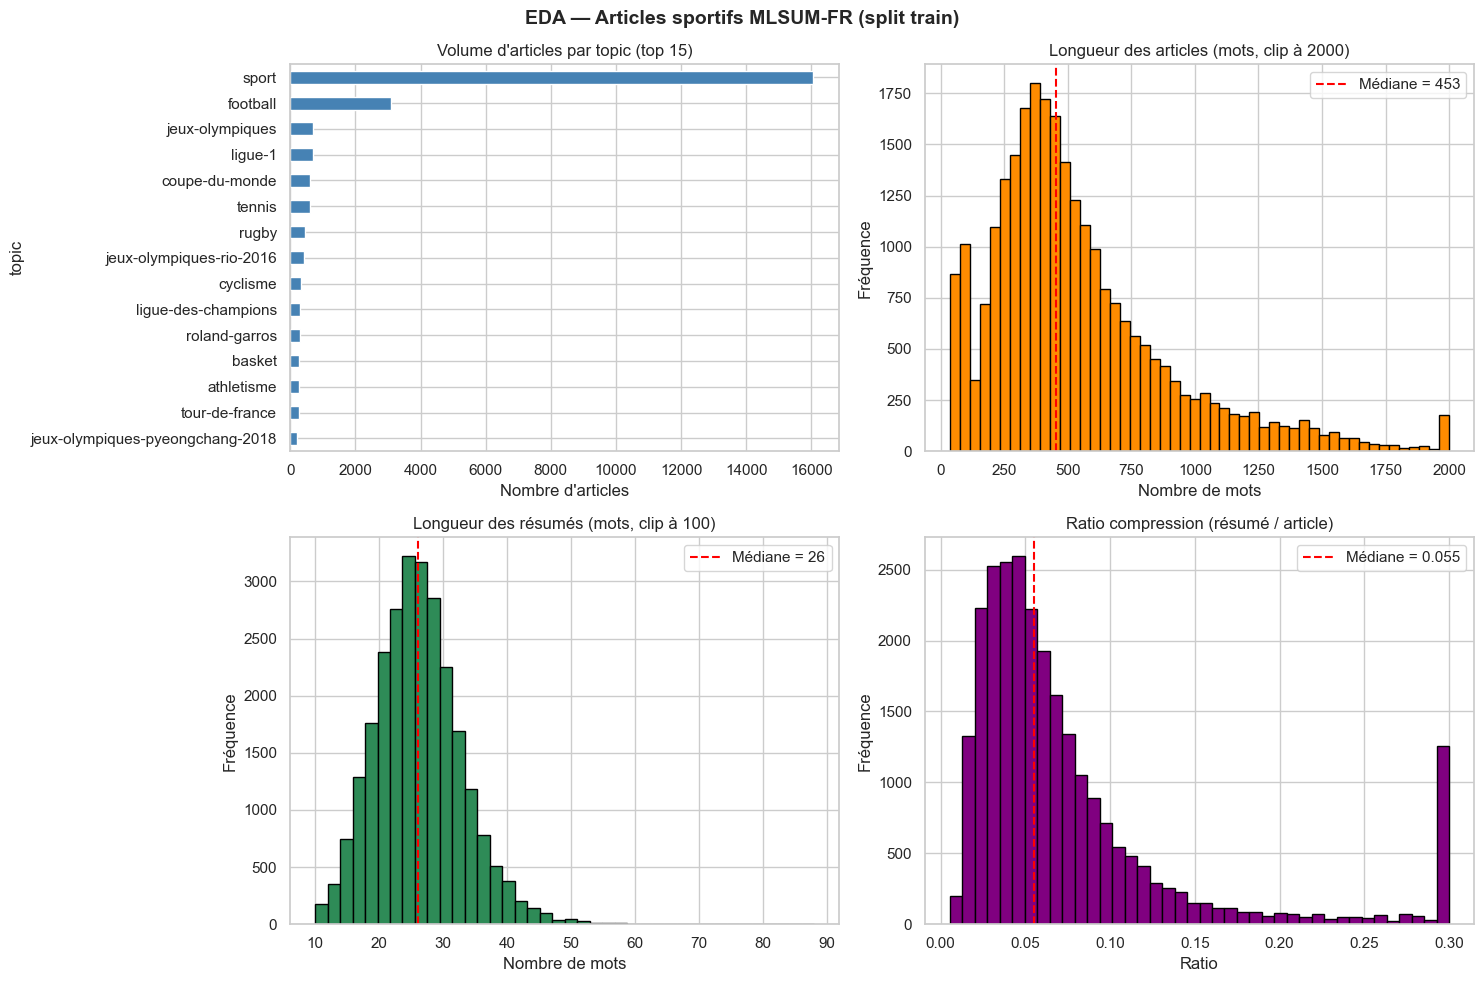

 graphique sauvegardée : ../figures/eda_overview.png


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("EDA — Articles sportifs MLSUM-FR (split train)", fontsize=14, fontweight="bold")

# 1. Volume par topic (top 15)
ax = axes[0, 0]
topic_counts.head(15).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Volume d'articles par topic (top 15)")
ax.set_xlabel("Nombre d'articles")

# 2. Distribution longueur articles
ax = axes[0, 1]
df["article_words"].clip(upper=2000).hist(bins=50, ax=ax, color="darkorange", edgecolor="black")
ax.axvline(df["article_words"].median(), color="red", linestyle="--", label=f"Médiane = {int(df['article_words'].median())}")
ax.set_title("Longueur des articles (mots, clip à 2000)")
ax.set_xlabel("Nombre de mots")
ax.set_ylabel("Fréquence")
ax.legend()

# 3. Distribution longueur résumés
ax = axes[1, 0]
df["summary_words"].clip(upper=100).hist(bins=40, ax=ax, color="seagreen", edgecolor="black")
ax.axvline(df["summary_words"].median(), color="red", linestyle="--", label=f"Médiane = {int(df['summary_words'].median())}")
ax.set_title("Longueur des résumés (mots, clip à 100)")
ax.set_xlabel("Nombre de mots")
ax.set_ylabel("Fréquence")
ax.legend()

# 4. Ratio de compression
ax = axes[1, 1]
df["compression_ratio"].clip(upper=0.3).hist(bins=40, ax=ax, color="purple", edgecolor="black")
ax.axvline(df["compression_ratio"].median(), color="red", linestyle="--", label=f"Médiane = {df['compression_ratio'].median():.3f}")
ax.set_title("Ratio compression (résumé / article)")
ax.set_xlabel("Ratio")
ax.set_ylabel("Fréquence")
ax.legend()

plt.tight_layout()

# Sauvegarde pour le README
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)
plt.savefig(FIGURES_DIR / "eda_overview.png", dpi=120, bbox_inches="tight")

plt.show()

print(f" graphique sauvegardée : {FIGURES_DIR / 'eda_overview.png'}")

In [40]:
# 3 échantillons aléatoires (on va vévifier la reproductibilité)
samples = df.sample(n=3, random_state=42).reset_index(drop=True)

for i, row in samples.iterrows():
    print("-" * 10)
    print(f"ÉCHANTILLON {i+1}  |  topic: {row['topic']}  |  {row['article_words']} mots → {row['summary_words']} mots")

    print(f"\n TITRE : {row['title']}\n")
    print(f" ARTICLE (extrait, 500 premiers caractères) :")
    print(row["text"][:500] + "...\n")
    print(f"RÉSUMÉ DE RÉFÉRENCE :")
    print(row["summary"])
    print()

----------
ÉCHANTILLON 1  |  topic: sport  |  706 mots → 15 mots

 TITRE : Le PSG réussit son retour en Ligue des champions

 ARTICLE (extrait, 500 premiers caractères) :
Marco Verratti étreint Zlatan Ibrahimovic après son premier but avec le PSG en Ligue des champions, mardi 18 septembre au Parc des Princes. AFP/KENZO TRIBOUILLARD Les 42 000 spectateurs massés dans les tribunes agitent drapeaux et lampions tandis que le speaker du Parc des Princes introduit avec solennité le cérémonial d'avant-match. "Certains ne connaissent pas cette musique, d'autres l'attendaient depuis longtemps", s'époumone-t-il au micro. La sono diffuse alors l'hymne de la Ligue des champi...

RÉSUMÉ DE RÉFÉRENCE :
Après huit années d'absence, le club parisien s'est largement imposé face au Dynamo Kiev (4-1)

----------
ÉCHANTILLON 2  |  topic: sport  |  182 mots → 39 mots

 TITRE : XV de France : Bonnaire et Poitrenaud face à l'Irlande

 ARTICLE (extrait, 500 premiers caractères) :
Clément Poitrenaud. REUTERS/C

## 6. Conclusion 


- Dataset filtré : **28 024 articles sportifs** (train: 26 119, val: 808, test: 1 097)
- 34 topics sportifs différents, plus de topics nommés par `sport` (généraliste) et `football`
- Articles : médiane 453 mots, distribution avec longue queue (max 6 391)
- Résumés : médiane 26 mots, distribution gaussienne resserrée (10–50 mots)
- Ratio de compression médian de 5.5 % → tâche de résumé abstractif classique

**Choix pour les hyperparametre grace au notebook EDA :**


 `max_source_length` : 1024 tokens / Couvre 95 % des articles sans troncature significative 
 `max_target_length` : 64 tokens / 2× la médiane des résumés, marge confortable 
 Filtrage outliers : Optionnel / Quelques articles très courts à ratio > 0.5 
 Volume train fine-tuning : 5 000 articles 
